In [7]:
# Michele Bianco: 17.10.2025
import numpy as np, random
from scipy.linalg import norm
from tqdm import tqdm

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
import astropy.constants as cst

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from utils_rt import refine_grid_2d
from utils_rtplot import plot_irregular_grid_cells, plot_ray

## Define Source & Target Positions

In [37]:
# box mesh and cell (physical) size
meshsize = 6
dL = 0.1 * u.cm

# position target cell
r_target = np.array([4.5, 5.5])
print('target:', r_target)

# source position
r_source = np.array([1.5, 1.5])
print('source:', r_source)

# vector from source to target
r_st = r_target - r_source
n_st = r_st/norm(r_st)
print('source to target:', n_st)
print('distance:', norm(r_st))

target: [4.5 5.5]
source: [1.5 1.5]
source to target: [0.6 0.8]
distance: 5.0


## Define Regular Grid

In [9]:
# define position of the refinde cells
#refine_cells = [(3, 3), (3, 4), (4, 3), (4, 4), (5, 3), (5, 4), (3, 5), (4, 5), (5, 5)]
refine_cells = []

# define level of the refined cells (resolution: 2^levels, similar to Ramses-RT)
#levels = {(3, 3): 2, (3, 4): 1, (4, 3): 1, (4, 4): 1, (5, 3): 1, (5, 4): 1, (3, 5): 1, (4, 5): 1, (5, 5): 1}
levels = {}

# Create refined 2D grid (no specific convention)
x_grid, y_grid, dr = refine_grid_2d(meshsize=meshsize, refine_cells=refine_cells, levels=levels)

# Coordinate of each cells (at the center of the cell)
r_c = np.vstack((x_grid, y_grid)).T

# define density grid
ndens = ((4e-31 * u.g/u.cm**3) / (cst.m_p+cst.m_e)  / dr).cgs

# create density grid (this is an overkill for a regular grid, but it will be usefull for irregualr case later)
ndens_grid = np.zeros((meshsize, meshsize))
for i_c, (i,j) in enumerate((r_c - dr[:,None]/2).astype(int)):
    ndens_grid[i,j] = ndens[i_c].value

For simplicity, here we look only at one specific direction.

In [10]:
# only rays in the direction of the the target
mask_x = (r_c[:, 0] <= r_target[0]) * (r_c[:, 0] >= r_source[0])
mask_y = (r_c[mask_x, 1] <= r_target[1]) * (r_c[mask_x, 1] >= r_source[1])

# cells position
r_cell = r_c[mask_x][mask_y]
dr_grid = dr[mask_x][mask_y]

print(r_cell.shape[0])

# source to each cells vector
r_sc = r_cell - r_source

# norm vector from source to target
r_st = r_target-r_source
n_st = r_st/np.linalg.norm(r_st)

print(n_st, np.linalg.norm(n_st))

20
[0.6 0.8] 1.0


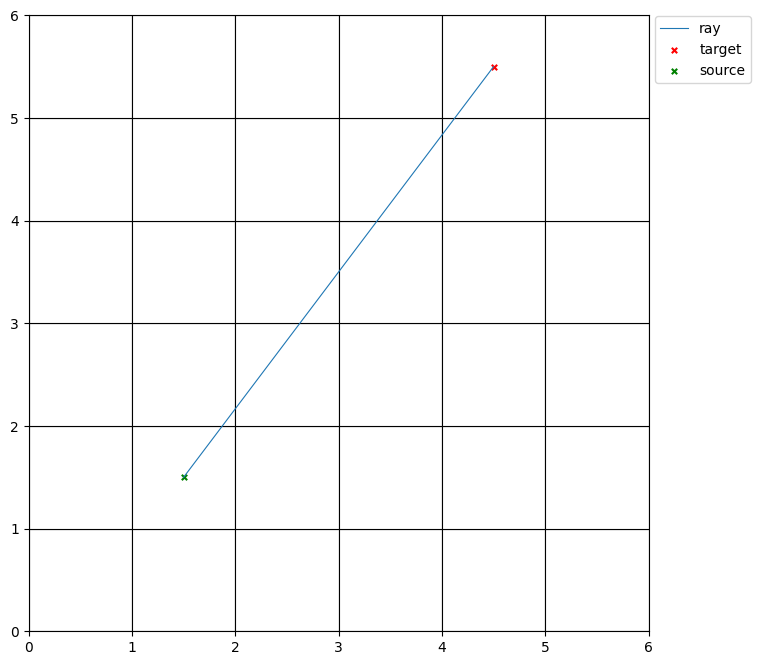

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))

# plot grid with cell boundaries and refinement
plot_irregular_grid_cells(r_c=r_c, dr=dr, ax=ax)

# plot ray
x_plot, y_plot = plot_ray(r_s=r_source, r_t=r_target)
ax.plot(x_plot, y_plot, lw=0.8, label='ray')

# plot target and source
ax.scatter(x=r_target[0], y=r_target[1], s=15, marker='x', color='red', label='target')
ax.scatter(x=r_source[0], y=r_source[1], s=15, marker='x', color='green', label='source')

ax.set_xlim(0, meshsize)
ax.set_ylim(0, meshsize)
plt.legend(loc=(1.01,0.89))
plt.show()

## The Short-Characteristics Raytracing Algorithm

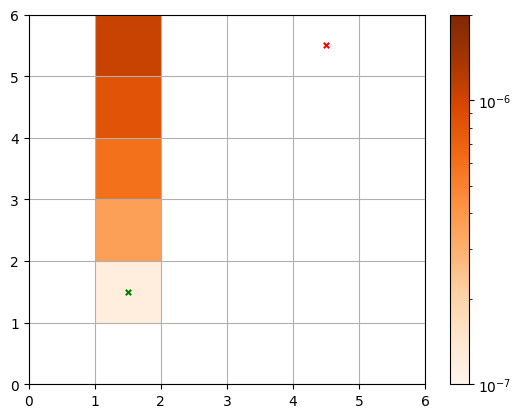

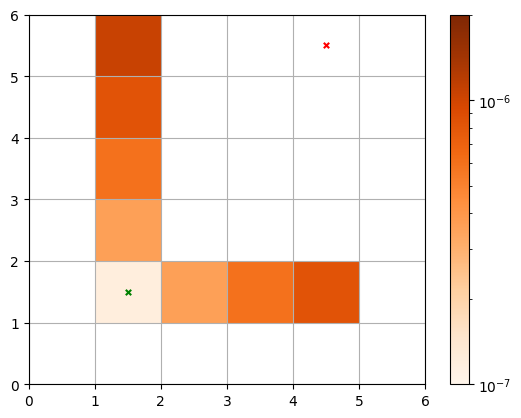

(None, None)

<Figure size 640x480 with 0 Axes>

In [23]:
# column density to the target
ncols = np.zeros((meshsize, meshsize))

# mask cells straight above and to the right
mask_yray = r_cell[:, 0] == r_source[0]
mask_xray = r_cell[:, 1] == r_source[1]

# loop over the cells in the y-direction of the target
for i_c, (r_c, dr_c) in enumerate(zip(r_cell[mask_yray], dr_grid[mask_yray])):
    # integerts to write into the grid
    i, j = (r_c - dr_c/2).astype(int)

    # path length crossing the cells right above
    path = 0.5*dr_c
        
    # calculate column density for this ray
    if(i_c == 0):
        ncols[i,j] = ndens_grid[i,j] * path
    else:
        ncols[i,j] = ncols[i,j-1] + ndens_grid[i,j-1]*0.5*dr_grid[mask_yray][i_c-1] + ndens_grid[i,j] * path

plt.pcolormesh(np.unique(x_grid), np.unique(y_grid), ncols.T, cmap='Oranges', norm='log', vmin=1e-7, vmax=2e-6)
plt.colorbar()

# plot target and source
plt.scatter(x=r_target[0], y=r_target[1], s=15, marker='x', color='red', label='target')
plt.scatter(x=r_source[0], y=r_source[1], s=15, marker='x', color='green', label='source')
plt.grid()
plt.show(), plt.clf()

# loop over the cells in the x-direction of the target
for i_c, (r_c, dr_c) in enumerate(zip(r_cell[mask_xray], dr_grid[mask_xray])):
    # integerts to write into the grid
    i, j = (r_c - dr_c/2).astype(int)

    # path length crossing the cells right above
    path = 0.5*dr_c
        
    # calculate column density for this ray
    if(i_c == 0):
        ncols[i,j] = ndens_grid[i,j] * path
    else:
        ncols[i,j] = ncols[i-1,j] + ndens_grid[i-1,j]*0.5*dr_grid[mask_yray][i_c-1] + ndens_grid[i,j] * path

plt.pcolormesh(np.unique(x_grid), np.unique(y_grid), ncols.T, cmap='Oranges', norm='log', vmin=1e-7, vmax=2e-6)
plt.colorbar()

# plot target and source
plt.scatter(x=r_target[0], y=r_target[1], s=15, marker='x', color='red', label='target')
plt.scatter(x=r_source[0], y=r_source[1], s=15, marker='x', color='green', label='source')
plt.grid()
plt.show(), plt.clf()

In [40]:
# mask cells that we need to interpolate
mask_to_interp = (r_cell[:, 0] != r_source[0]) * (r_cell[:, 1] != r_source[1])

for i_c, (r_c, dr_c) in enumerate(zip(r_cell[mask_to_interp], dr_grid[mask_to_interp])):
    # integerts to write into the grid
    i, j = (r_c - dr_c/2).astype(int)

    r_cleft = np.array([r_c[0]-dr_c, r_c[1]])
    r_clow = np.array([r_c[0], r_c[1]-dr_c])

    # distance between the cell (center) and the source (center)
    delt_i = r_c[0] - r_source[0]
    delt_j = r_c[1] - r_source[1]
    
    sig_i = np.abs(delt_i)/delt_i
    sig_j = np.abs(delt_j)/delt_j
    
    # vector from source to cells
    r_sc = r_c - r_source
    n_sc = r_st/norm(r_sc)

    #print(r_c, r_source, delt_i, delt_j)
    print(r_c, r_cleft, r_clow)

[2.5 2.5] [1.5 2.5] [2.5 1.5]
[2.5 3.5] [1.5 3.5] [2.5 2.5]
[2.5 4.5] [1.5 4.5] [2.5 3.5]
[2.5 5.5] [1.5 5.5] [2.5 4.5]
[3.5 2.5] [2.5 2.5] [3.5 1.5]
[3.5 3.5] [2.5 3.5] [3.5 2.5]
[3.5 4.5] [2.5 4.5] [3.5 3.5]
[3.5 5.5] [2.5 5.5] [3.5 4.5]
[4.5 2.5] [3.5 2.5] [4.5 1.5]
[4.5 3.5] [3.5 3.5] [4.5 2.5]
[4.5 4.5] [3.5 4.5] [4.5 3.5]
[4.5 5.5] [3.5 5.5] [4.5 4.5]


In [39]:
np.abs(-2)

2

In [37]:
# column density to the target
ncols = np.zeros((meshsize, meshsize))

# loop over the cells in the direction of the target (this is only to compare with long-charaterisitcs)
for r_c in r_cell:
    i, j = (r_c - 0.5).astype(int)
    
    # half the cell size
    path = 0.5*dr_cell
    
    # distance between the cell (center) and the source (center)
    delt_i = r_c[0] - r_source[0]
    delt_j = r_c[1] - r_source[1]
    
    # orientation of r_sc vector
    sign_i = np.sign(delt_i)
    sign_j = np.sign(delt_j)

    if (delt_i == 0) and (delt_j == 0):
        # Origin cell
        ncols_in = 0.0
        ncols[i, j] = ncols_in + path*ndens[i,j]
    elif (delt_i == 0 and delt_j != 0): 
        # Ray propagating along y-axis
        
        # previous column density calculation (up to the cell's center)
        ncols_in = ncols[i,j-1]
        
        if (delt_j > 1):
            # add the missing half step (after the cell's center)
            ncols_in += path*ndens[i,j-1]
        
        ncols[i,j] = ncols_in + path*ndens[i,j]
    elif (delt_j == 0 and delt_i != 0): 
        # Ray propagating along x-axis
        
        # previous column density calculation (up to the cell's center)
        ncols_in = ncols[i-1,j]
        
        if (delt_i > 1):
            # add the missing half step (after the cell's center)
            ncols_in += path*ndens[i-1,j]
        
        ncols[i,j] = ncols_in + path*ndens[i,j]
    elif (delt_i == delt_j and delt_i != 0 and delt_j != 0):
        # Ray propagating along diagonal of the cell
        
        # previous column density calculation (up to the cell's center)        
        ncols_in = ncols[i-1,j-1]
        
        # previous column density calculation (up to the cell's center)
        if (delt_i == 1 and delt_j == 1):
            ncols_in *= np.sqrt(2)
        elif (delt_i > 1):
            # add the missing half step (after the cell's center)
            ncols_in += path*np.sqrt(2)*ndens[i-1,j-1]
            
        ncols[i,j] = ncols_in + path*np.sqrt(2)*ndens[i,j]
        
#plt.imshow(ncols, vmin=0, origin='lower')
#plt.colorbar()
#plt.show()

# same as before but need to be separated (cross direction first)
for r_c in r_cell:
    i, j = (r_c - 0.5).astype(int)
    
    # half the cell size
    path = 0.5*dr_cell
    
    # distance between the cell (center) and the source (center)
    delt_i = r_c[0] - r_source[0]
    delt_j = r_c[1] - r_source[1]
    
    # orientation of r_sc vector
    sign_i = np.sign(delt_i)
    sign_j = np.sign(delt_j)
    
    if (delt_i == 0) and (delt_j == 0):
        pass
    elif (delt_i == 0): 
        pass
    elif (delt_j == 0): 
        pass
    elif(np.abs(delt_i) > np.abs(delt_j)):
        ds = np.sqrt(1 + delt_j**2/delt_i**2)

        xc = r_c[0] - sign_i*path
        yc = delt_j/delt_i * (delt_i - sign_i*path) + r_source[1]

        #dy = 2*np.abs(yc - (r_c[1] - sign_j*0.5))
        dy = 2*np.abs(xc - (i - sign_i*0.5))
        w1, w2 = (1.-dy)/np.max([0.6,ncols[i-1,j]*sigma_HI_at_ion_freq]), dy/np.max([0.6,ncols[i-1,j-1]*sigma_HI_at_ion_freq])
        
        ncols_in = (w1*ncols[i-1,j] + w2*ncols[i-1,j-1])/(w1+w2)
        ncols[i,j] = ncols_in + ds*ndens[i,j]

    elif(np.abs(delt_j) > np.abs(delt_i)):
        ds = np.sqrt(delt_i**2/delt_j**2 + 1)

        xc = delt_i/delt_j * (delt_j - sign_j*path) + r_source[0]
        yc = r_c[1]-sign_j*path

        dx = 2*np.abs(xc - (r_c[0] - sign_i*0.5))
        
        w1, w2 = (1.-dx)/np.max([0.6,ncols[i,j-1]*sigma_HI_at_ion_freq]), dx/np.max([0.6,ncols[i-1,j-1]*sigma_HI_at_ion_freq])
        
        ncols_in = (w1*ncols[i,j-1] + w2*ncols[i-1,j-1])/(w1+w2)
        ncols[i,j] = ncols_in + ds*ndens[i,j]

plt.imshow(ncols, vmin=0, origin='lower')
plt.colorbar()
plt.show()

NameError: name 'dr_cell' is not defined

In [43]:
np.max([0.6,ncols[i,j-1]*sigma_HI_at_ion_freq])

0.6

In [44]:
ndens[1,1]*np.sqrt(2)*path*2

0.0014142135623730952

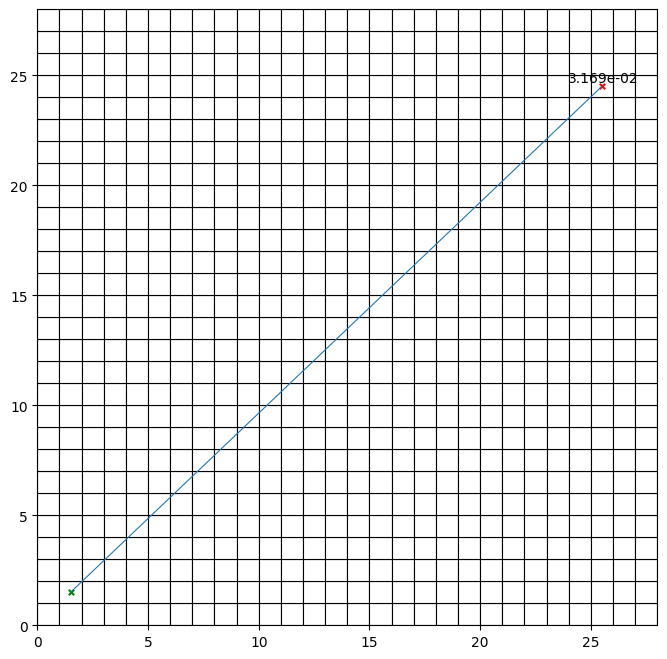

(None, None)

<Figure size 640x480 with 0 Axes>

In [45]:
fig, ax = plt.subplots(figsize=(8, 8))

# plot grid with cell boundaries and refinement
plot_irregular_grid_cells(r_c=r_grid, dr=dr, ax=ax)

# plot ray
x_plot, y_plot = plot_ray(r_s=r_source, r_t=r_target)
ax.plot(x_plot, y_plot, lw=0.8, label='ray')

# plot target and source
ax.scatter(x=r_target[0], y=r_target[1], s=15, marker='x', color='red', label='target')
ax.scatter(x=r_source[0], y=r_source[1], s=15, marker='x', color='green', label='source')

ax.set_xlim([0, HII_DIM])
ax.set_ylim([0, HII_DIM])
"""

for xx in r_cell[:,0]:
    for yy in r_cell[:,1]:
        plt.text(x=xx+0.05, y=yy+0.05, s='%.1e' %ncols[int(xx-0.5),int(yy-0.5)], ha='center', va='bottom')
plt.text(x=xx+0.05, y=yy+0.05, s='%.1e' %ncols[int(xx-0.5),int(yy-0.5)], ha='center', va='bottom')
"""
i_t, j_t = (r_target-0.5).astype(int)
plt.text(x=i_t+0.55, y=j_t+0.55, s='%.3e' %ncols[i_t, j_t], ha='center', va='bottom')

plt.savefig('rt_shortchar_grid.png', bbox_inches='tight')
plt.show(), plt.clf()

In [182]:
ncols[i_t, j_t]

0.03391064892046592